In [131]:
%load_ext autoreload
%autoreload 2

import tempfile
from pathlib import Path

import albumentations as A
import cv2 as cv
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from pipelime.sequences import SamplesSequence

from generated import GeneratorConfig
from src.generator import LogoDatasetGenerator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
IMG_SIZE = 256

config = GeneratorConfig(
    logos_dir=Path("../data/logos/train/data"),
    backgrounds_dir=Path("../data/backgrounds"),
    output_size=[518, 518],
    length=500,
    negative_ratio=0.1,
    seed=42,
    max_retries=5,
    logo_transform=A.Compose(
        [
            A.LongestMaxSize(max_size=IMG_SIZE),
            # Position / scale / rotation invariance
            A.Affine(
                scale=(0.2, 0.7),
                rotate=(-180, 180),
                shear=(-30, 30),
                translate_percent={
                    "x": (-0.5, 0.5),
                    "y": (-0.5, 0.5),
                },
                border_mode=cv.BORDER_CONSTANT,
                fill=0,
                p=1.0,
            ),
            # Perspective invariance
            A.Perspective(
                scale=(0.05, 0.20),
                keep_size=True,
                border_mode=cv.BORDER_CONSTANT,
                fill=0,
                p=0.7,
            ),
            # Color invariance
            A.HueSaturationValue(
                hue_shift_limit=180,
                sat_shift_limit=(-5, 80),
                val_shift_limit=(-30, 50),
                p=1.0,
            ),
            A.OneOf(
                [
                    A.RGBShift(
                        r_shift_limit=80,
                        g_shift_limit=80,
                        b_shift_limit=80,
                        p=1.0,
                    ),
                    A.ChannelShuffle(p=1.0),
                    A.ColorJitter(
                        brightness=0.4,
                        contrast=0.4,
                        saturation=0.8,
                        hue=0.5,
                        p=1.0,
                    ),
                ],
                p=0.8,
            ),
            A.ToGray(p=0.05),
            # Illumination invariance
            A.OneOf(
                [
                    A.RandomGamma(
                        gamma_limit=(70, 140),
                        p=1.0,
                    ),
                    A.RandomBrightnessContrast(
                        brightness_limit=0.35,
                        contrast_limit=0.35,
                        p=1.0,
                    ),
                ],
                p=0.35,
            ),
        ],
    ),
    composition_transform=A.Compose(
        [],
        bbox_params=A.BboxParams(
            format="coco",
            label_fields=["labels"],
            min_visibility=0.1,
        ),
    ),
)

In [133]:
tmpdir = tempfile.TemporaryDirectory()

black_bg = np.zeros((config.output_size[1], config.output_size[0], 3), dtype=np.uint8)
black_bg_path = Path(tmpdir.name) / "black_bg.png"
cv.imwrite(str(black_bg_path), black_bg)

config.backgrounds_dir = Path(tmpdir.name)

output_dir = Path(tmpdir.name) / "generated"
generator = LogoDatasetGenerator(config)
generator.write_underfolder(output_dir, exists_ok=True)
seq = SamplesSequence.from_underfolder(output_dir)

2026-04-25 12:55:58.683 | INFO     | src.generator:__init__:49 - Found 3 logos, 1 backgrounds
🍋: 100%|██████████| 500/500 [00:05<00:00, 84.38it/s]
2026-04-25 12:56:04.610 | INFO     | src.generator:write_underfolder:68 - Wrote 500 samples to /tmp/tmpqujji1wj/generated


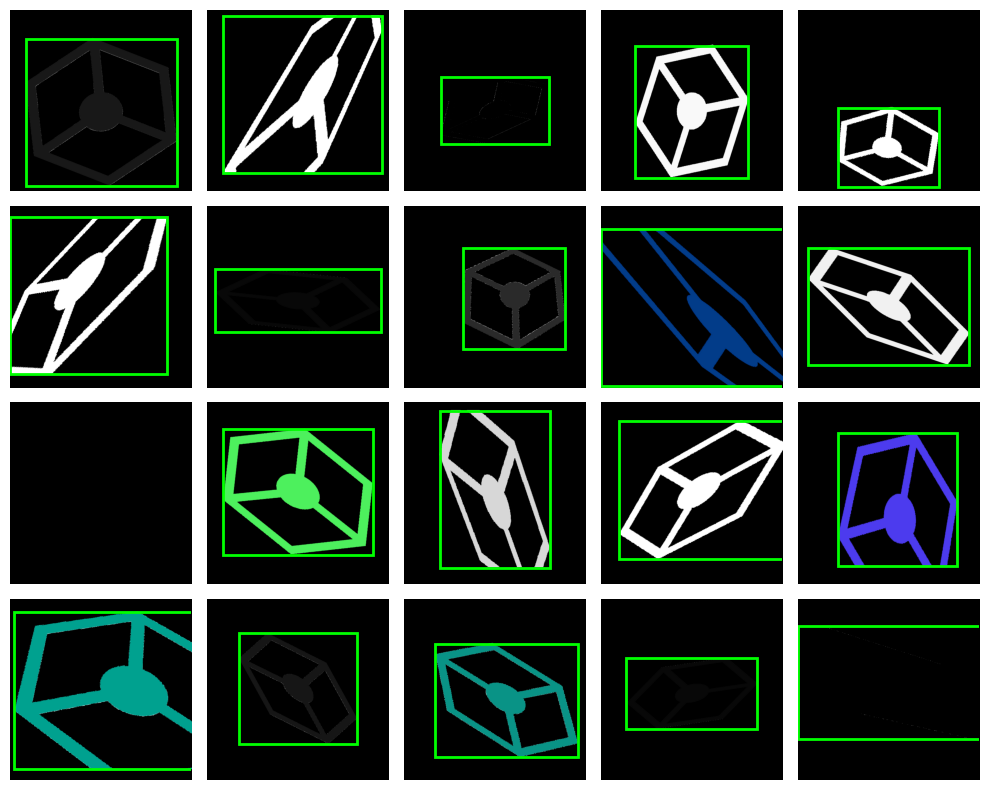

In [130]:
N_ROWS, N_COLS = 4, 5
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 2, N_ROWS * 2))

for ax, sample in zip(axes.flatten(), seq):
    img = sample["image"]()
    bboxes = sample["bboxes"]()

    ax.imshow(img)
    for bbox in bboxes:
        x, y, w, h = bbox
        ax.add_patch(
            patches.Rectangle(
                (x, y), w, h, linewidth=2, edgecolor="lime", facecolor="none"
            )
        )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [128]:
def plot_logo_heatmap(
    seq: SamplesSequence,
    canvas_size: tuple[int, int],
) -> None:
    h, w = canvas_size
    heatmap = np.zeros((h, w), dtype=np.float64)

    for sample in seq:
        for bbox in sample["bboxes"]():
            x, y, bw, bh = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            heatmap[y : y + bh, x : x + bw] += 1

    heatmap /= heatmap.sum() or 1

    plt.figure(figsize=(6, 6))
    plt.imshow(heatmap, cmap="magma")
    plt.title("Logo position heatmap")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

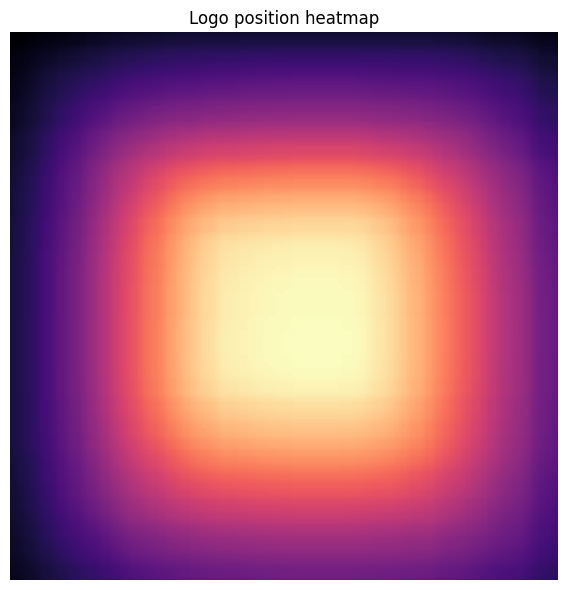

In [89]:
plot_logo_heatmap(seq, config.output_size)

In [90]:
def plot_hue_coverage(seq: SamplesSequence, sat_threshold: int = 30) -> None:
    hues = []

    for sample in seq:
        bboxes = sample["bboxes"]()
        if bboxes.shape[0] == 0:
            continue
        img = sample["image"]()
        for bbox in bboxes:
            x, y, w, h = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            roi = img[y : y + h, x : x + w]
            hsv = cv.cvtColor(roi, cv.COLOR_RGB2HSV)
            mask = hsv[..., 1] > sat_threshold
            hues.append(hsv[mask, 0])

    all_hues = np.concatenate(hues)
    #! hue values are in [0, 179], we convert them to radians for the polar plot
    angles = all_hues.astype(np.float64) / 180.0 * 2 * np.pi

    n_bins = 60
    counts, edges = np.histogram(angles, bins=n_bins, range=(0, 2 * np.pi))
    centers = (edges[:-1] + edges[1:]) / 2

    colors = []
    for c in centers:
        h_cv = int(c / (2 * np.pi) * 180) % 180
        rgb = cv.cvtColor(np.uint8([[[h_cv, 255, 255]]]), cv.COLOR_HSV2RGB)[0, 0]
        colors.append(rgb / 255.0)

    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(5, 5))
    ax.bar(
        centers,
        counts,
        width=2 * np.pi / n_bins,
        color=colors,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.set_title("Hue coverage", va="bottom", pad=20)
    plt.tight_layout()
    plt.show()

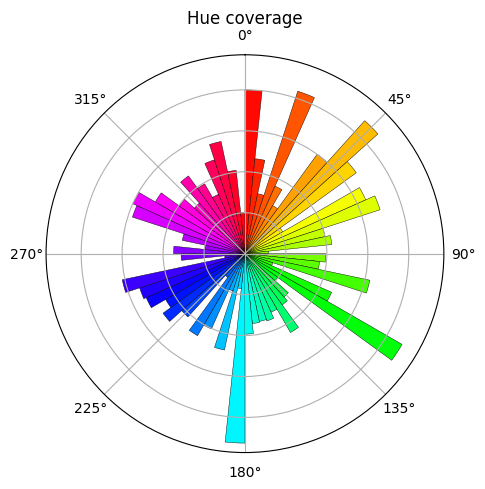

In [91]:
plot_hue_coverage(seq)

In [13]:
tmpdir.cleanup()